---
# **機械システム制御特論　課題（2）**
## **伝達関数から根軌跡を描画**
---

### 1. 伝達関数の定義
伝達関数を任意の個数だけリストに定義する．各伝達関数は辞書型で`num`（分子）と`den`（分母）を次数の大きい順にリストで定義する．

In [3]:
import control as ctrl
import matplotlib.pyplot as plt
import numpy as np

# Define the transfer functions for both cases
tf = [
    # G(s) = 1 / (s(s+1)(s+3))
    {
        'num': [1],
        'den': [1, 4, 3, 0]
    }, 

    # G(s) = 1 / (s(s+1)(s+2)(s+3))
    {
        'num': [1],
        'den': [1, 6, 11, 6, 0]
    }
]

### 2. 根軌跡の極／零点，漸近線，分岐点の計算
伝達関数の個数だけ根軌跡の極／零点，漸近線，分岐点の計算をする．

In [23]:
import sympy as sp

for G_dist in tf:
    s = sp.Symbol('s')

    num = sp.Poly(G_dist['num'], s).as_expr()
    den = sp.Poly(G_dist['den'], s).as_expr()

    # Calculate poles and zeros
    poles = sp.solve(den, s)
    zeros = sp.solve(num, s)

    n_p = len(poles)
    n_z = len(zeros)

    # Calculate asymptotes (if n_p > n_z)
    if n_p > n_z:
        centroid = (sum(poles) - sum(zeros)) / (n_p - n_z)
        angles_rad = [(2*k + 1) * sp.pi / (n_p - n_z) for k in range(n_p - n_z)]
        angles_deg = [sp.simplify(angle * 180 / sp.pi) for angle in angles_rad] # 度数法に変換
    else:
        centroid = None
        angles_deg = []

    # Compute all saddle points (candidates for breakaway)
    K_expr = -den / num
    dK_ds = sp.diff(K_expr, s)
    all_saddle_points = sp.solve(dK_ds, s)

    valid_breakaway = []
    invalid_breakaway = []

    for pt in all_saddle_points:
        K_val = sp.simplify(K_expr.subs(s, pt))
        
        try:
            K_num = complex(K_val.evalf())
            # Check if K is real and positive
            if abs(K_num.imag) < 1e-9 and K_num.real > 0:
                valid_breakaway.append(pt)
            else:
                invalid_breakaway.append(pt)
        except TypeError:
            invalid_breakaway.append(pt)

    # Calculate imaginary axis crossings
    K_sym = sp.Symbol('K', real=True)
    w_sym = sp.Symbol('w', real=True)
    
    char_eq = sp.expand(den + K_sym * num)
    char_eq_jw = sp.expand(char_eq.subs(s, sp.I * w_sym))
    
    re_part, im_part = char_eq_jw.as_real_imag()
    crossings_sols = sp.solve([re_part, im_part], (w_sym, K_sym), dict=True)
    
    imag_crossings = []
    critical_Ks = set()
    for sol in crossings_sols:
        try:
            K_val = complex(sol[K_sym].evalf())
            if abs(K_val.imag) < 1e-9 and K_val.real > 1e-9:
                w_val = sp.simplify(sol[w_sym])
                imag_crossings.append(sp.simplify(w_val * sp.I))
                critical_Ks.add(sp.simplify(sol[K_sym]))
        except TypeError:
            pass
    
    imag_crossings = list(set(imag_crossings))
    sorted_critical_Ks = sorted(list(critical_Ks), key=lambda x: float(x.evalf()))

    # Stability analysis based on critical K values
    K_boundaries = [sp.Integer(0)] + sorted_critical_Ks
    stable_intervals = []
    
    for i in range(len(K_boundaries)):
        if i < len(K_boundaries) - 1:
            test_K = (K_boundaries[i] + K_boundaries[i+1]) / 2
            interval_str = f"{K_boundaries[i]} < K < {K_boundaries[i+1]}"
        else:
            test_K = K_boundaries[i] + 10
            interval_str = f"K > {K_boundaries[i]}"
        
        test_eq = char_eq.subs(K_sym, test_K)
        test_roots = sp.Poly(test_eq, s).nroots()
        
        if all(float(sp.re(r)) < -1e-9 for r in test_roots):
            stable_intervals.append(interval_str)

    if not stable_intervals:
        stability_str = "None (Unstable for all K > 0)"
    else:
        stability_str = " or ".join(stable_intervals)

    # Output summary
    print("=" * 80)

    print(f"Transfer Function        : G(s) = {num} / ({sp.expand(den)})")

    print("-" * 80)

    print(f"Poles                    : {poles}")
    print(f"Zeros                    : {zeros}")

    print("-" * 80)

    if centroid is not None:
        print(f"Asymptote Centroid       : {centroid}")
        print(f"Asymptote Angles         : {angles_deg} [deg]")
    else:
        print("Asymptotes                : None")
    
    print("-" * 80)

    print(f"Valid Breakaway Points   : {valid_breakaway}")
    print(f"Imaginary Axis Crossings : {imag_crossings}")

    print("-" * 80)

    print(f"Critical Gains           : {sorted_critical_Ks}")
    print(f"Stability Margin         : {stability_str}")

    print("=" * 80)
    print("\n")

Transfer Function        : G(s) = 1 / (s**3 + 4*s**2 + 3*s)
--------------------------------------------------------------------------------
Poles                    : [-3, -1, 0]
Zeros                    : []
--------------------------------------------------------------------------------
Asymptote Centroid       : -4/3
Asymptote Angles         : [60, 180, 300] [deg]
--------------------------------------------------------------------------------
Valid Breakaway Points   : [-4/3 + sqrt(7)/3]
Imaginary Axis Crossings : [sqrt(3)*I, -sqrt(3)*I]
--------------------------------------------------------------------------------
Critical Gains           : [12]
Stability Margin         : 0 < K < 12


Transfer Function        : G(s) = 1 / (s**4 + 6*s**3 + 11*s**2 + 6*s)
--------------------------------------------------------------------------------
Poles                    : [-3, -2, -1, 0]
Zeros                    : []
--------------------------------------------------------------------------

### 3. 根軌跡の描画
伝達関数の個数だけ根軌跡を描画する．

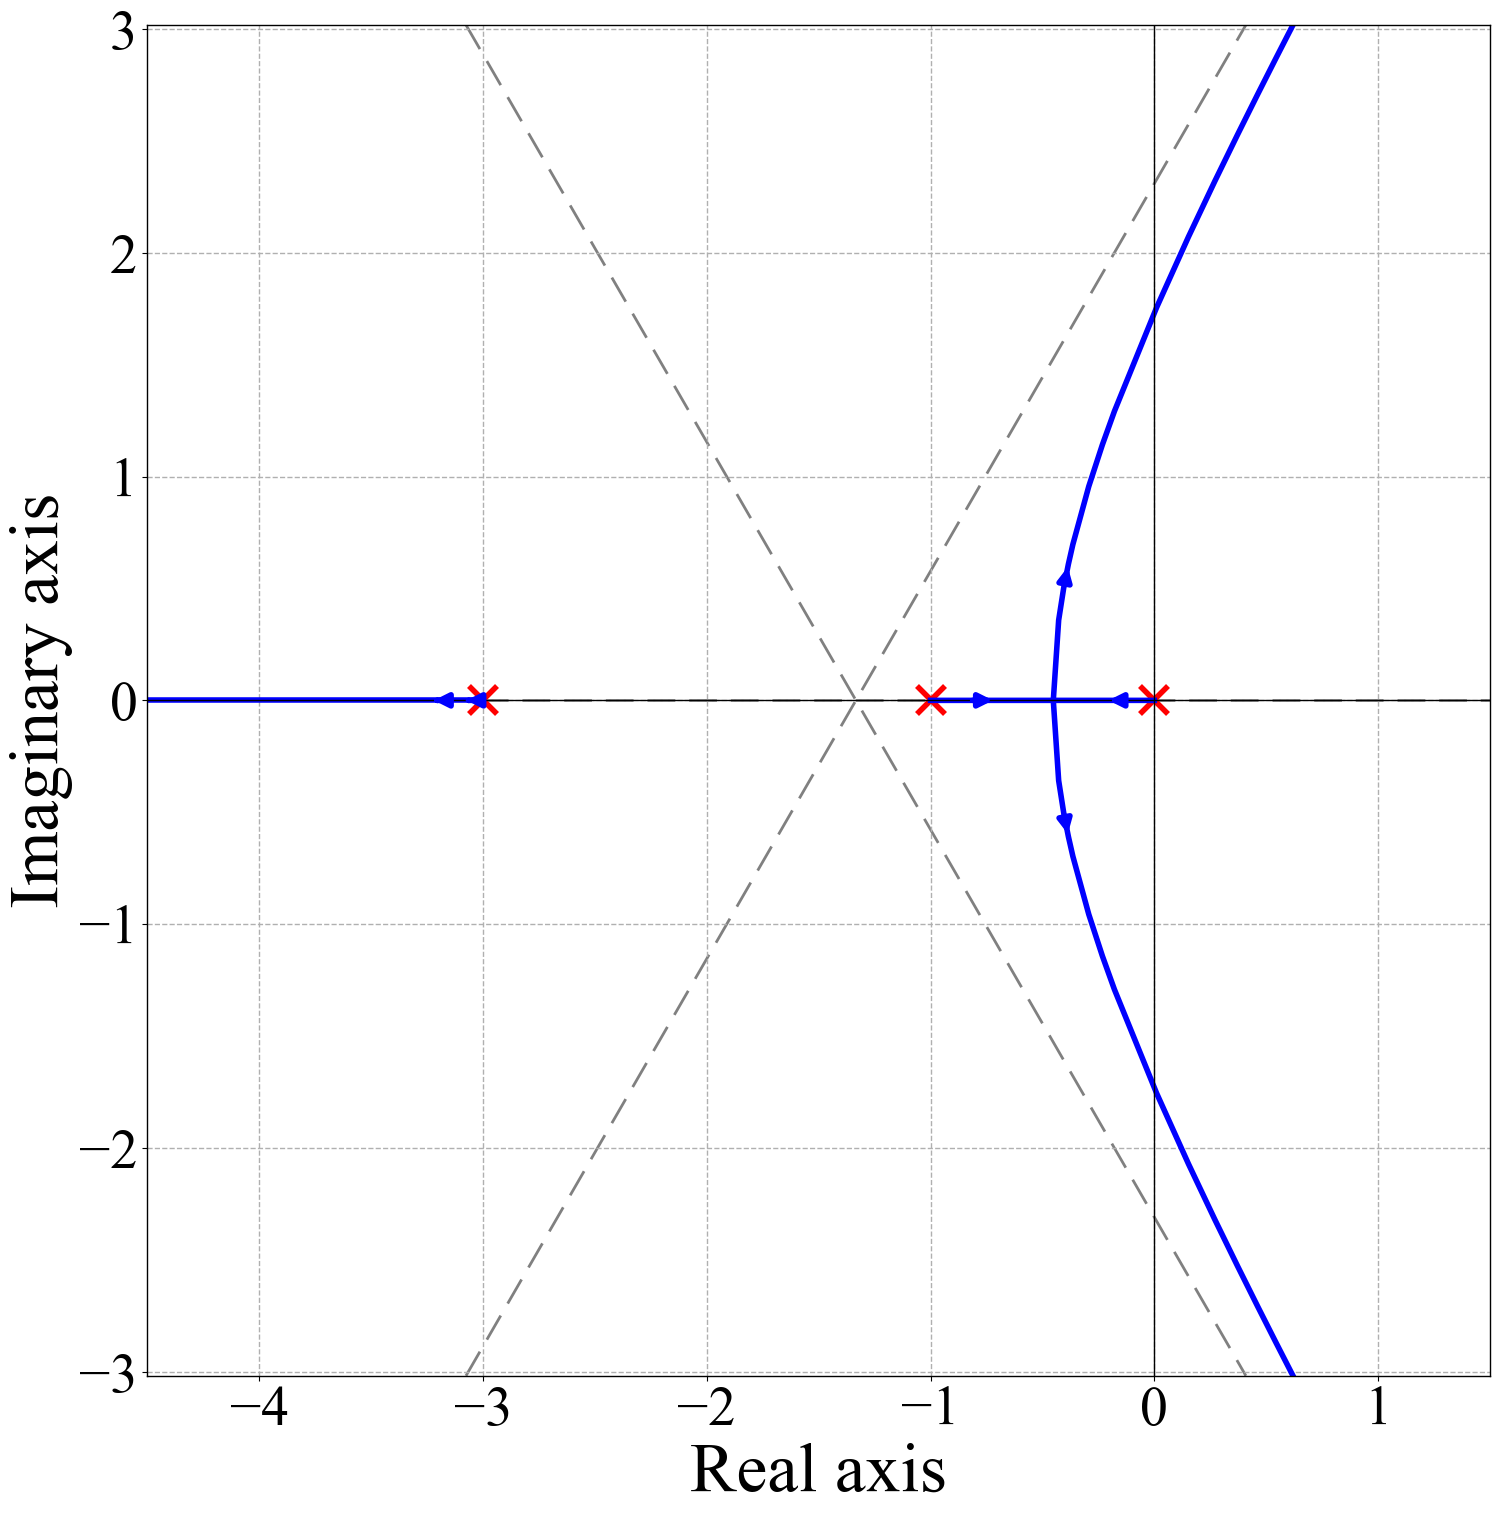

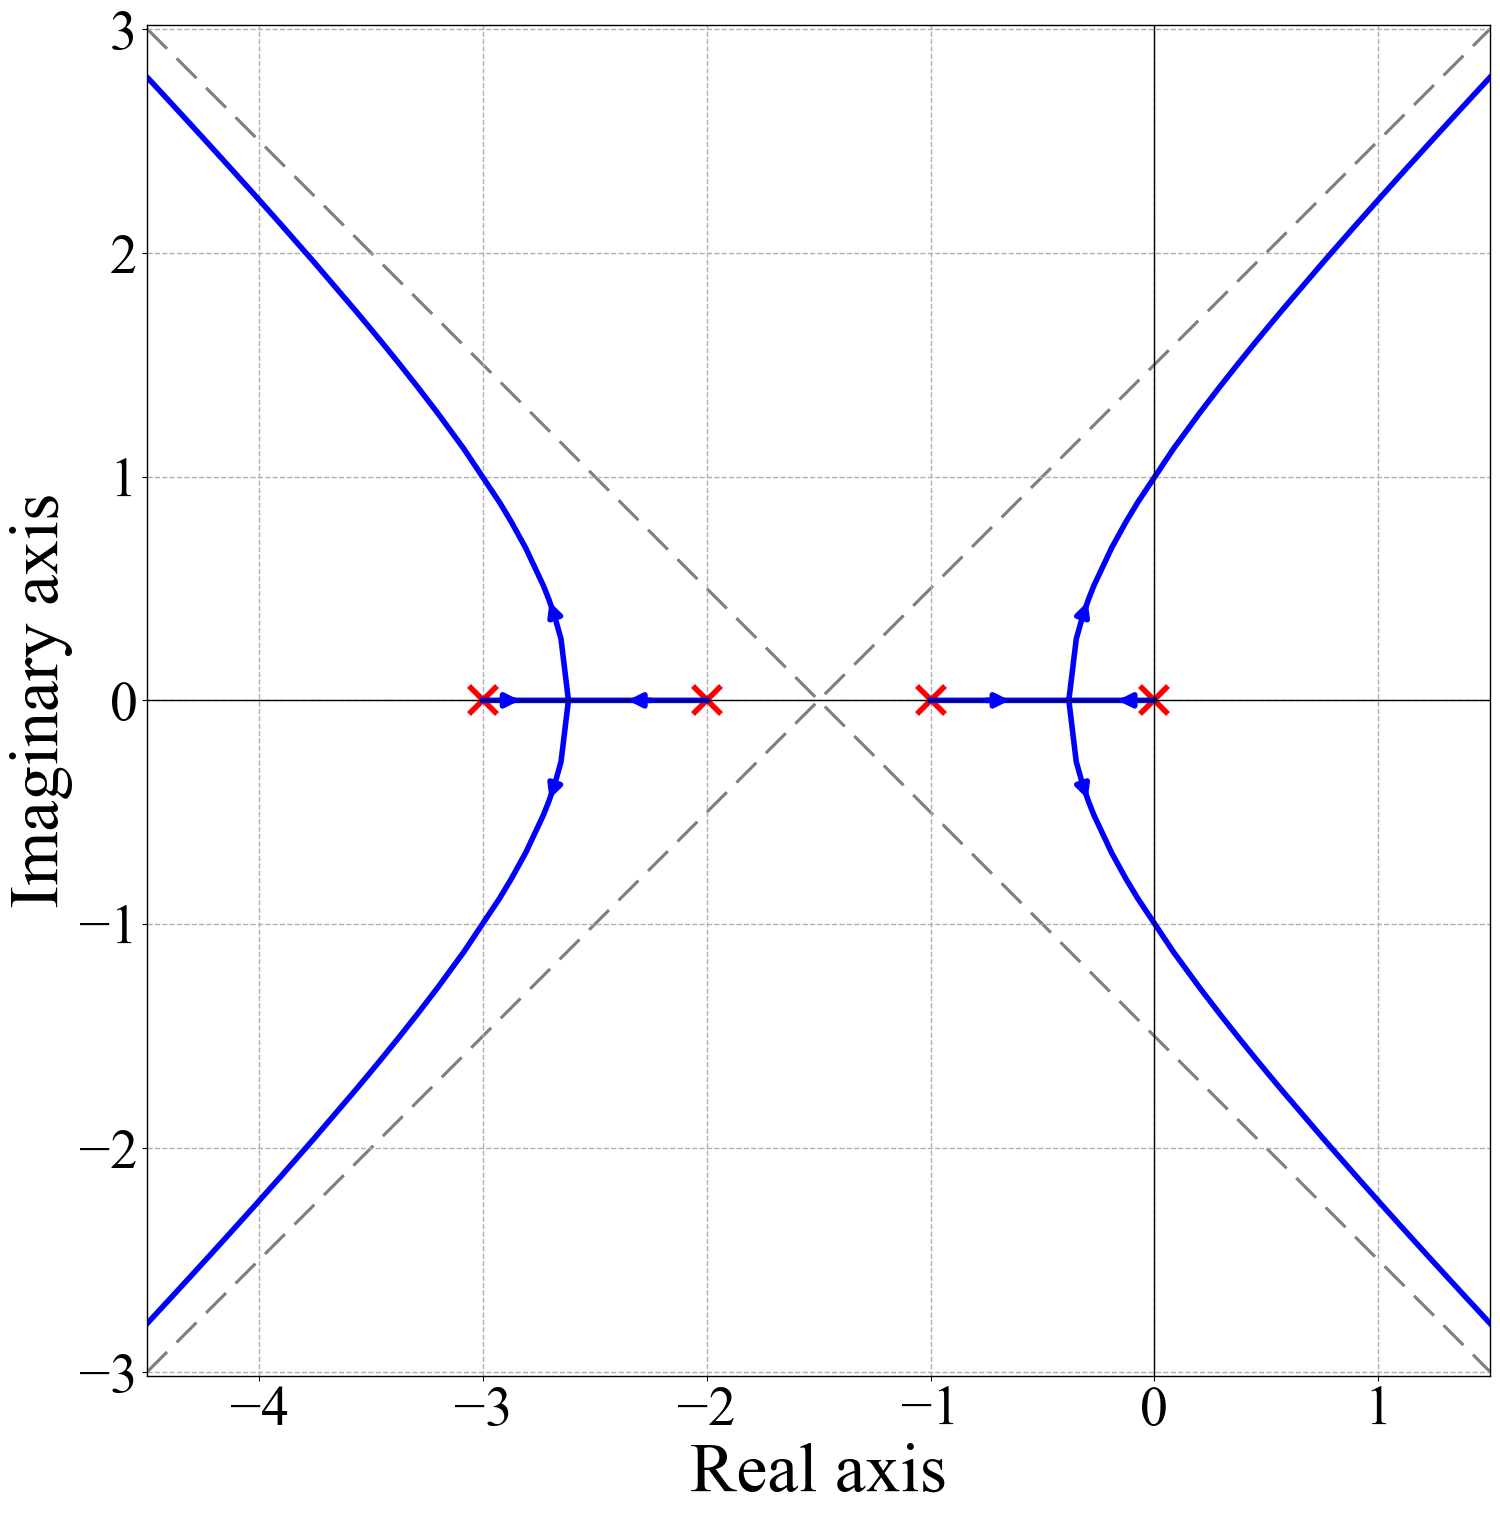

In [14]:
from matplotlib import rcParams

# Configure figure infomation
params = {
    'figure.autolayout':True,                    # Auto layout
    'font.family':'Times New Roman',#'Arial',    # Font setting
    'pdf.fonttype':42,                           # PDF font type
    'axes.linewidth':1.0,                        # Linewidth of axes
    'patch.linewidth':1.0,                       # Linewidth of legend
    'grid.linewidth':1.0,                        # Linewidth of grid
    'axes.labelsize':50,                         # Font size of axes label
    'font.size':40,                              # Text size　　　　　　
    'legend.fontsize':70,                        # Font size of legend
    'xtick.labelsize':40,                        # Font size of values in x axes
    'ytick.labelsize':40,                        # Font size of values in x axes
    'text.usetex':False,                         # For TeX font -> True
    'figure.figsize':[16, 9]#[8/2.54, 6/2.54]    # Output size (inch order)
}
rcParams.update(params)

for G_dist in tf:
    G = ctrl.TransferFunction(G_dist['num'], G_dist['den'])

    # Calculate root locus
    roots, gains = ctrl.root_locus(G, plot=False)

    fig, ax = plt.subplots(figsize=(16, 16))

    # Draw poles and zeros
    poles = ctrl.poles(G)
    zeros = ctrl.zeros(G)
    n_poles = len(poles)
    n_zeros = len(zeros)
    ax.plot(poles.real, poles.imag, 'x', markersize=20, markeredgewidth=4, color='red', label='Poles')
    if len(zeros) > 0:
        ax.plot(zeros.real, zeros.imag, 'o', markersize=20, markeredgewidth=4, markerfacecolor='none', color='red', label='Zeros')

    # Draw asymptotes if there are more poles than zeros
    sigma_a = None 
    if n_poles > n_zeros:
        sigma_a = (np.sum(poles.real) - np.sum(zeros.real)) / (n_poles - n_zeros)
        
        for k in range(n_poles - n_zeros):
            theta = (2 * k + 1) * np.pi / (n_poles - n_zeros)
            ax.axline(
                (sigma_a, 0), 
                (sigma_a + np.cos(theta), np.sin(theta)), 
                color='gray', linestyle=(0, (10, 5)), lw=2, zorder=0
            )

    # Draw root locus
    num_branches = roots.shape[1]

    for i in range(num_branches):
        branch = roots[:, i]

        # Plot the root locus branch
        ax.plot(branch.real, branch.imag, color='blue', lw=4)
        
        # Arrow placement for gain change visualization
        arrow_indices = [
            int(len(branch) * 0.04),
            int(len(branch) * 0.10), 
            int(len(branch) * 0.60)
        ]
        
        for idx in arrow_indices:
            if idx < len(branch) - 1:
                p1 = branch[idx]
                p2 = branch[idx + 1]
                
                if np.abs(p2 - p1) > 1e-5:
                    ax.annotate(
                        '', 
                        xy=(p2.real, p2.imag), 
                        xytext=(p1.real, p1.imag),
                        arrowprops=dict(arrowstyle='-|>', color='blue', lw=4, mutation_scale=20)
                    )

    # Set axes limits
    points = np.concatenate([poles, zeros]) if len(zeros) > 0 else poles
    x_min, x_max = np.min(points.real), np.max(points.real)
    y_min, y_max = np.min(points.imag), np.max(points.imag)
    x_margin = max(abs(x_max - x_min) * 0.5, 1.0)
    y_margin = max(abs(y_max - y_min) * 0.5, 1.0)
    plt.xlim(x_min - x_margin, x_max + x_margin)
    plt.ylim(y_min - y_margin, y_max + y_margin)
    plt.gca().set_aspect('equal', adjustable='datalim')

    # Draw axes and grid
    ax.axhline(0, color='black', lw=1) 
    ax.axvline(0, color='black', lw=1) 
    ax.grid(True, linestyle='--')
    ax.set_xlabel('Real axis')
    ax.set_ylabel('Imaginary axis')

    plt.show()